# Naive Bayes and K-Nearest Neighbors From Scratch

In this notebook, I will implement two common machine learning algorithms completely from scratch:

- K-Nearest Neighbors (KNN)
- Gaussian Naive Bayes

Rules for this notebook:
- No NumPy
- No pandas
- No scikit-learn
- No matplotlib
- Only pure Python logic and very small standard-library helpers

Notebook structure:
1. Create a synthetic dataset in code
2. Implement each algorithm from scratch
3. Visualize the dataset and the intuition behind each algorithm
4. Evaluate predictions using simple metrics

## 1. Imports

I will only use:
- `random` to generate synthetic data
- `math` for square roots, exponentials, and pi
- `IPython.display` only to show SVG images in the notebook

In [3]:
import random
import math
from IPython.display import SVG, display, HTML

## 2. Create a dataset from code

I want a dataset that is easy to understand visually.

Each sample will have:
- `x1`
- `x2`
- `label`

I will create two classes:
- Class 0 centered roughly around the lower-left area
- Class 1 centered roughly around the upper-right area

This will make both KNN and Naive Bayes easier to understand.

In [5]:
def generate_synthetic_dataset(n_per_class=30, seed=42):
    random.seed(seed)
    data = []

    # Class 0 cluster
    for _ in range(n_per_class):
        x1 = random.gauss(2.0, 0.8)
        x2 = random.gauss(2.0, 0.8)
        data.append([x1, x2, 0])

    # Class 1 cluster
    for _ in range(n_per_class):
        x1 = random.gauss(6.0, 0.8)
        x2 = random.gauss(6.0, 0.8)
        data.append([x1, x2, 1])

    return data

In [6]:
dataset = generate_synthetic_dataset(n_per_class=35, seed=7)

print("Total samples:", len(dataset))
print("First 5 samples:")
for row in dataset[:5]:
    print(row)

Total samples: 70
First 5 samples:
[1.7952957692419196, 2.4091452100132114, 0]
[1.8191230681735162, 1.7479452621350515, 0]
[1.255985447741786, 1.829358442063037, 0]
[2.8895339047890567, 2.339317347300749, 0]
[2.829503263111733, 2.199122182132073, 0]


## 3. Dataset format

Each row is:

[x1, x2, label]

Example:
[2.13, 1.87, 0]

This means:
- x1 = 2.13
- x2 = 1.87
- class = 0

In [8]:
def count_by_class(data):
    counts = {}
    for row in data:
        label = row[-1]
        counts[label] = counts.get(label, 0) + 1
    return counts

print("Class counts:", count_by_class(dataset))

Class counts: {0: 35, 1: 35}


## 4. Visualize the dataset

Since I am not using matplotlib, I will generate an SVG image manually.

This is still useful because:
- I can see the data distribution
- I can understand why KNN works locally
- I can understand why Gaussian Naive Bayes may also work here

In [10]:
def get_feature_bounds(data, padding=1.0):
    x_values = [row[0] for row in data]
    y_values = [row[1] for row in data]

    min_x = min(x_values) - padding
    max_x = max(x_values) + padding
    min_y = min(y_values) - padding
    max_y = max(y_values) + padding

    return min_x, max_x, min_y, max_y


def scale_point(x, y, min_x, max_x, min_y, max_y, width, height, margin=40):
    usable_width = width - 2 * margin
    usable_height = height - 2 * margin

    sx = margin + (x - min_x) / (max_x - min_x) * usable_width

    # SVG y-axis goes downward, so flip vertically
    sy = height - margin - (y - min_y) / (max_y - min_y) * usable_height

    return sx, sy


def dataset_to_svg(data, width=500, height=500):
    min_x, max_x, min_y, max_y = get_feature_bounds(data)

    svg_parts = []
    svg_parts.append(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg">')
    svg_parts.append(f'<rect x="0" y="0" width="{width}" height="{height}" fill="white" stroke="black"/>')

    # axes
    svg_parts.append(f'<line x1="40" y1="{height-40}" x2="{width-20}" y2="{height-40}" stroke="black"/>')
    svg_parts.append(f'<line x1="40" y1="{height-40}" x2="40" y2="20" stroke="black"/>')

    svg_parts.append(f'<text x="{width/2}" y="{height-10}" font-size="14" text-anchor="middle">x1</text>')
    svg_parts.append(f'<text x="15" y="{height/2}" font-size="14" text-anchor="middle" transform="rotate(-90,15,{height/2})">x2</text>')

    for row in data:
        x, y, label = row
        sx, sy = scale_point(x, y, min_x, max_x, min_y, max_y, width, height)

        color = "steelblue" if label == 0 else "tomato"
        svg_parts.append(f'<circle cx="{sx}" cy="{sy}" r="5" fill="{color}" opacity="0.8"/>')

    # legend
    svg_parts.append(f'<circle cx="{width-140}" cy="30" r="6" fill="steelblue"/>')
    svg_parts.append(f'<text x="{width-125}" y="35" font-size="13">Class 0</text>')
    svg_parts.append(f'<circle cx="{width-140}" cy="55" r="6" fill="tomato"/>')
    svg_parts.append(f'<text x="{width-125}" y="60" font-size="13">Class 1</text>')

    svg_parts.append('</svg>')
    return "".join(svg_parts)

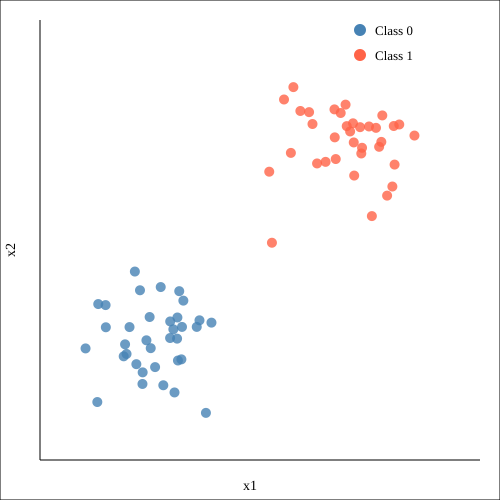

In [11]:
display(SVG(dataset_to_svg(dataset)))

## 5. Split the data into training and testing sets

I will do this manually.

Idea:
- shuffle the data
- keep 80% for training
- keep 20% for testing

In [13]:
def train_test_split(data, test_ratio=0.2, seed=42):
    copied = data[:]
    random.seed(seed)
    random.shuffle(copied)

    split_index = int(len(copied) * (1 - test_ratio))
    train_data = copied[:split_index]
    test_data = copied[split_index:]

    return train_data, test_data

In [14]:
train_data, test_data = train_test_split(dataset, test_ratio=0.2, seed=10)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))
print("Training class counts:", count_by_class(train_data))
print("Testing class counts:", count_by_class(test_data))

Training samples: 56
Testing samples: 14
Training class counts: {1: 28, 0: 28}
Testing class counts: {0: 7, 1: 7}


## 6. K-Nearest Neighbors (KNN) from scratch

KNN is one of the easiest algorithms to understand.

Core idea:
1. Take a new point
2. Measure its distance to every training point
3. Choose the `k` closest points
4. Let them vote
5. Predict the majority class

Important:
- KNN does not really "train" a model in the traditional sense
- it stores the training data
- prediction happens at query time

In [16]:
def euclidean_distance(row1, row2):
    # row format: [x1, x2, label]
    # Only use features, not the label
    total = 0.0
    for i in range(len(row1) - 1):
        diff = row1[i] - row2[i]
        total += diff * diff
    return math.sqrt(total)

In [17]:
def get_neighbors(train_data, test_row, k):
    distances = []

    for train_row in train_data:
        dist = euclidean_distance(train_row, test_row)
        distances.append((train_row, dist))

    distances.sort(key=lambda item: item[1])

    neighbors = []
    for i in range(k):
        neighbors.append(distances[i][0])

    return neighbors, distances

In [18]:
def majority_vote(neighbors):
    votes = {}
    for row in neighbors:
        label = row[-1]
        votes[label] = votes.get(label, 0) + 1

    best_label = None
    best_count = -1

    for label, count in votes.items():
        if count > best_count:
            best_count = count
            best_label = label

    return best_label

In [19]:
class KNNFromScratch:
    def __init__(self, k=3):
        self.k = k
        self.train_data = None

    def fit(self, train_data):
        self.train_data = train_data[:]

    def predict_one(self, test_row):
        neighbors, _ = get_neighbors(self.train_data, test_row, self.k)
        return majority_vote(neighbors)

    def predict(self, test_data):
        predictions = []
        for row in test_data:
            pred = self.predict_one(row)
            predictions.append(pred)
        return predictions

In [20]:
knn = KNNFromScratch(k=3)
knn.fit(train_data)

knn_predictions = knn.predict(test_data)
print("First 10 KNN predictions:", knn_predictions[:10])

First 10 KNN predictions: [0, 0, 0, 1, 1, 0, 1, 1, 1, 0]


## 7. Evaluation helpers

I will compute:
- accuracy
- confusion matrix

This is enough for a small educational notebook.

In [22]:
def accuracy_score(true_labels, predicted_labels):
    correct = 0
    for i in range(len(true_labels)):
        if true_labels[i] == predicted_labels[i]:
            correct += 1
    return correct / len(true_labels)


def confusion_matrix_binary(true_labels, predicted_labels):
    # format:
    # TN FP
    # FN TP
    tn = fp = fn = tp = 0

    for t, p in zip(true_labels, predicted_labels):
        if t == 0 and p == 0:
            tn += 1
        elif t == 0 and p == 1:
            fp += 1
        elif t == 1 and p == 0:
            fn += 1
        elif t == 1 and p == 1:
            tp += 1

    return [[tn, fp], [fn, tp]]

In [23]:
y_test = [row[-1] for row in test_data]

knn_acc = accuracy_score(y_test, knn_predictions)
knn_cm = confusion_matrix_binary(y_test, knn_predictions)

print("KNN Accuracy:", round(knn_acc, 4))
print("KNN Confusion Matrix:")
for row in knn_cm:
    print(row)

KNN Accuracy: 1.0
KNN Confusion Matrix:
[7, 0]
[0, 7]


## 8. KNN intuition visualization

I want an illustration that explains *how* KNN makes a decision.

For one chosen test point:
- draw all training points
- highlight the query point
- circle its nearest neighbors
- show the predicted class

In [25]:
def knn_explanation_svg(train_data, test_row, k=3, width=520, height=520):
    min_x, max_x, min_y, max_y = get_feature_bounds(train_data + [test_row])

    neighbors, distances = get_neighbors(train_data, test_row, k)
    neighbor_ids = set(id(row) for row in neighbors)

    qx, qy = test_row[0], test_row[1]
    sqx, sqy = scale_point(qx, qy, min_x, max_x, min_y, max_y, width, height)

    svg_parts = []
    svg_parts.append(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg">')
    svg_parts.append(f'<rect x="0" y="0" width="{width}" height="{height}" fill="white" stroke="black"/>')

    # axes
    svg_parts.append(f'<line x1="40" y1="{height-40}" x2="{width-20}" y2="{height-40}" stroke="black"/>')
    svg_parts.append(f'<line x1="40" y1="{height-40}" x2="40" y2="20" stroke="black"/>')

    # training points
    for row in train_data:
        x, y, label = row
        sx, sy = scale_point(x, y, min_x, max_x, min_y, max_y, width, height)

        color = "steelblue" if label == 0 else "tomato"
        radius = 5

        if id(row) in neighbor_ids:
            svg_parts.append(f'<circle cx="{sx}" cy="{sy}" r="10" fill="none" stroke="gold" stroke-width="3"/>')

        svg_parts.append(f'<circle cx="{sx}" cy="{sy}" r="{radius}" fill="{color}" opacity="0.85"/>')

    # query point
    svg_parts.append(f'<circle cx="{sqx}" cy="{sqy}" r="8" fill="black"/>')
    svg_parts.append(f'<text x="{sqx + 10}" y="{sqy - 10}" font-size="13">Query</text>')

    predicted = majority_vote(neighbors)

    svg_parts.append(f'<text x="20" y="20" font-size="14">KNN explanation (k={k})</text>')
    svg_parts.append(f'<text x="20" y="40" font-size="14">Predicted class: {predicted}</text>')
    svg_parts.append(f'<text x="20" y="60" font-size="12">Gold circles = nearest neighbors</text>')

    svg_parts.append('</svg>')
    return "".join(svg_parts)

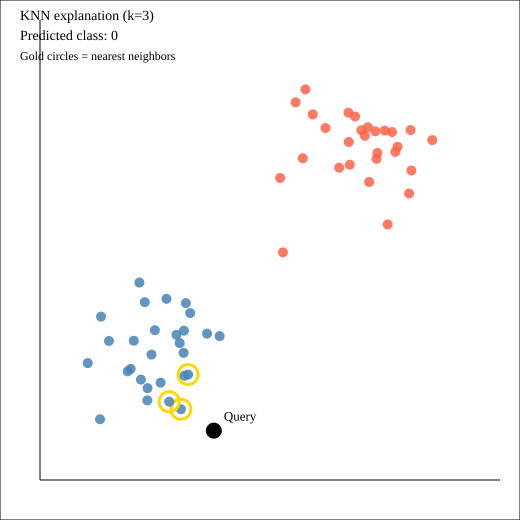

In [26]:
example_test_row = test_data[0]
display(SVG(knn_explanation_svg(train_data, example_test_row, k=3)))

### KNN interpretation

What happened here?

- The black point is the query point
- The gold outlined points are the `k` closest training samples
- Their labels vote
- The majority class becomes the prediction

This is why KNN is called a **lazy learner**:
- it stores examples
- it delays real decision-making until prediction time

## 9. Gaussian Naive Bayes from scratch

Naive Bayes is based on probability.

For a class `c`, we want:

P(class = c | features)

Using Bayes' rule:

P(c | x) ∝ P(c) * P(x | c)

The "naive" assumption says:
- features are conditionally independent given the class

So for two features x1 and x2:

P(x1, x2 | c) = P(x1 | c) * P(x2 | c)

Because my features are continuous, I will use **Gaussian Naive Bayes**.

That means each feature inside each class is modeled by a normal distribution:
- mean
- variance

In [29]:
def separate_by_class(data):
    separated = {}
    for row in data:
        label = row[-1]
        if label not in separated:
            separated[label] = []
        separated[label].append(row)
    return separated

In [30]:
def mean(values):
    total = 0.0
    for v in values:
        total += v
    return total / len(values)


def variance(values):
    m = mean(values)
    total = 0.0
    for v in values:
        diff = v - m
        total += diff * diff
    # small educational choice: population variance
    return total / len(values)


def stdev(values):
    return math.sqrt(variance(values))

In [31]:
def summarize_dataset(rows):
    # Exclude label column
    summaries = []
    num_features = len(rows[0]) - 1

    for i in range(num_features):
        feature_values = [row[i] for row in rows]
        feature_mean = mean(feature_values)
        feature_variance = variance(feature_values)

        # avoid zero-variance problems
        if feature_variance == 0:
            feature_variance = 1e-9

        summaries.append((feature_mean, feature_variance))

    return summaries

In [32]:
def summarize_by_class(data):
    separated = separate_by_class(data)
    summaries = {}

    for class_value, rows in separated.items():
        summaries[class_value] = {
            "prior": len(rows) / len(data),
            "feature_summaries": summarize_dataset(rows),
            "count": len(rows)
        }

    return summaries

In [33]:
def gaussian_probability(x, mu, var):
    exponent = math.exp(-((x - mu) ** 2) / (2 * var))
    return (1 / math.sqrt(2 * math.pi * var)) * exponent

In [34]:
class GaussianNaiveBayesFromScratch:
    def __init__(self):
        self.class_summaries = None

    def fit(self, train_data):
        self.class_summaries = summarize_by_class(train_data)

    def calculate_class_probabilities(self, input_row):
        probabilities = {}

        for class_value, info in self.class_summaries.items():
            prior = info["prior"]
            feature_summaries = info["feature_summaries"]

            prob = prior

            for i in range(len(feature_summaries)):
                mu, var = feature_summaries[i]
                x = input_row[i]
                prob *= gaussian_probability(x, mu, var)

            probabilities[class_value] = prob

        return probabilities

    def predict_one(self, input_row):
        probabilities = self.calculate_class_probabilities(input_row)

        best_class = None
        best_prob = -1

        for class_value, prob in probabilities.items():
            if prob > best_prob:
                best_prob = prob
                best_class = class_value

        return best_class

    def predict(self, test_data):
        predictions = []
        for row in test_data:
            predictions.append(self.predict_one(row))
        return predictions

In [35]:
gnb = GaussianNaiveBayesFromScratch()
gnb.fit(train_data)

gnb_predictions = gnb.predict(test_data)
print("First 10 Gaussian NB predictions:", gnb_predictions[:10])

First 10 Gaussian NB predictions: [0, 0, 0, 1, 1, 0, 1, 1, 1, 0]


In [36]:
gnb_acc = accuracy_score(y_test, gnb_predictions)
gnb_cm = confusion_matrix_binary(y_test, gnb_predictions)

print("Gaussian Naive Bayes Accuracy:", round(gnb_acc, 4))
print("Gaussian Naive Bayes Confusion Matrix:")
for row in gnb_cm:
    print(row)

Gaussian Naive Bayes Accuracy: 1.0
Gaussian Naive Bayes Confusion Matrix:
[7, 0]
[0, 7]


## 10. What did Naive Bayes actually learn?

Unlike KNN, Naive Bayes builds a compact probabilistic summary.

For each class, it learns:
- prior probability
- mean of feature 1
- variance of feature 1
- mean of feature 2
- variance of feature 2

In [38]:
for class_value, info in gnb.class_summaries.items():
    print(f"Class {class_value}")
    print("  Prior:", round(info["prior"], 4))
    for i, (mu, var) in enumerate(info["feature_summaries"]):
        print(f"  Feature {i+1}: mean={round(mu,4)}, variance={round(var,4)}")
    print()

Class 1
  Prior: 0.5
  Feature 1: mean=6.0789, variance=0.7184
  Feature 2: mean=6.0853, variance=0.4945

Class 0
  Prior: 0.5
  Feature 1: mean=1.8375, variance=0.4665
  Feature 2: mean=1.9728, variance=0.5117



## 11. Naive Bayes intuition visualization

For Naive Bayes, I want a picture that explains:
- each class has its own feature distributions
- a new point gets scored under each class
- the class with the larger probability wins

In [40]:
def naive_bayes_explanation_svg(model, query_row, width=760, height=380):
    probs = model.calculate_class_probabilities(query_row)

    x1 = query_row[0]
    x2 = query_row[1]

    class0 = model.class_summaries[0]
    class1 = model.class_summaries[1]

    c0_f1_mu, c0_f1_var = class0["feature_summaries"][0]
    c0_f2_mu, c0_f2_var = class0["feature_summaries"][1]

    c1_f1_mu, c1_f1_var = class1["feature_summaries"][0]
    c1_f2_mu, c1_f2_var = class1["feature_summaries"][1]

    predicted = 0 if probs[0] > probs[1] else 1

    svg = f'''
    <svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg">
      <rect x="0" y="0" width="{width}" height="{height}" fill="white" stroke="black"/>

      <text x="20" y="30" font-size="22">Gaussian Naive Bayes intuition</text>

      <rect x="20" y="60" width="330" height="130" fill="#f3f7ff" stroke="steelblue"/>
      <text x="35" y="90" font-size="18" fill="steelblue">Class 0 model</text>
      <text x="35" y="120" font-size="14">Prior = {class0["prior"]:.4f}</text>
      <text x="35" y="145" font-size="14">x1 ~ N(mean={c0_f1_mu:.2f}, var={c0_f1_var:.2f})</text>
      <text x="35" y="170" font-size="14">x2 ~ N(mean={c0_f2_mu:.2f}, var={c0_f2_var:.2f})</text>

      <rect x="400" y="60" width="330" height="130" fill="#fff3f0" stroke="tomato"/>
      <text x="415" y="90" font-size="18" fill="tomato">Class 1 model</text>
      <text x="415" y="120" font-size="14">Prior = {class1["prior"]:.4f}</text>
      <text x="415" y="145" font-size="14">x1 ~ N(mean={c1_f1_mu:.2f}, var={c1_f1_var:.2f})</text>
      <text x="415" y="170" font-size="14">x2 ~ N(mean={c1_f2_mu:.2f}, var={c1_f2_var:.2f})</text>

      <rect x="20" y="220" width="710" height="120" fill="#fafafa" stroke="#666"/>
      <text x="35" y="250" font-size="18">Query point</text>
      <text x="35" y="278" font-size="14">x1 = {x1:.3f}, x2 = {x2:.3f}</text>
      <text x="35" y="306" font-size="14">Score for class 0 ∝ {probs[0]:.10f}</text>
      <text x="35" y="330" font-size="14">Score for class 1 ∝ {probs[1]:.10f}</text>

      <text x="430" y="278" font-size="18">Predicted class: {predicted}</text>
      <text x="430" y="306" font-size="13">Naive assumption:</text>
      <text x="430" y="326" font-size="13">P(x1, x2 | c) = P(x1 | c) · P(x2 | c)</text>
    </svg>
    '''
    return svg

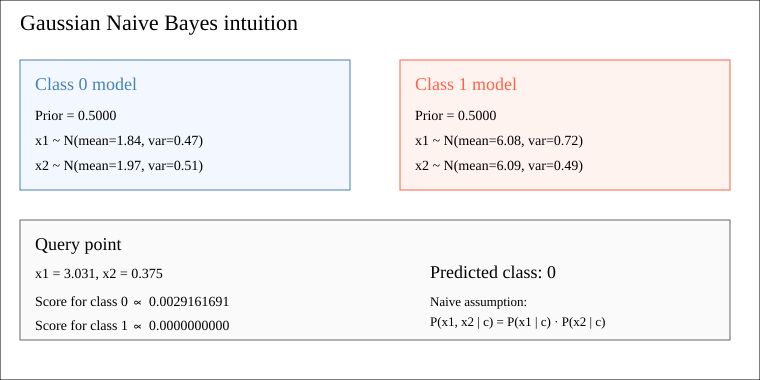

In [41]:
display(SVG(naive_bayes_explanation_svg(gnb, test_data[0])))

## 12. Compare the two algorithms conceptually

### KNN
- Memory-based
- No real parameter learning
- Uses local neighborhoods
- Sensitive to distance scale
- Easy to understand geometrically

### Gaussian Naive Bayes
- Learns class summaries
- Very fast at prediction
- Based on probability
- Assumes conditional independence
- Assumes Gaussian feature distributions

In [43]:
print("Final Summary")
print("-" * 40)
print("KNN accuracy:", round(knn_acc, 4))
print("Gaussian Naive Bayes accuracy:", round(gnb_acc, 4))

Final Summary
----------------------------------------
KNN accuracy: 1.0
Gaussian Naive Bayes accuracy: 1.0
